# Knowledge Graph — ML Features, Recommendations, and LLM Q&A

Build a typed knowledge graph from tabular data, then:
- Extract 22+ ML features per entity (for XGBoost, LightGBM, sklearn)
- Find structurally similar accounts
- Generate peer-based recommendations
- Ask LLM questions grounded in graph data

**No API calls needed for graph construction.** Runs locally in milliseconds.

## 1. Generate data (500 accounts × 14 columns)

In [1]:
import random
from faker import Faker
fake = Faker(); Faker.seed(42); random.seed(42)

INDUSTRIES = ['SaaS', 'Fintech', 'Healthcare IT', 'E-commerce', 'Cybersecurity', 'AI/ML Platform', 'DevOps']
TECH = ['AWS', 'GCP', 'Azure', 'Kubernetes', 'Docker', 'Terraform', 'Python', 'Go', 'Rust', 'PostgreSQL', 'Redis', 'Kafka']
PRODUCTS = ['CDN', 'WAF', 'DDoS Protection', 'Zero Trust', 'CASB', 'Workers', 'R2', 'AI Gateway']
USE_CASES = ['cloud_security', 'data_protection', 'edge_compute', 'api_security', 'compliance']

records = []
for i in range(500):
    company = fake.company().replace(',', '')
    stage = random.choice(['Prospect', 'Customer', 'POC', 'Churned'])
    records.append({
        'account_id': f'A{i+1:04d}', 'company': company,
        'industry': random.choice(INDUSTRIES),
        'region': random.choice(['US', 'EMEA', 'APAC', 'LATAM']),
        'segment': random.choice(['Enterprise', 'Mid-Market', 'SMB']),
        'employees': random.choice([50, 200, 500, 2000, 10000]),
        'revenue': random.choice([5e6, 50e6, 200e6, 1e9]),
        'stage': stage,
        'tech_stack': ', '.join(random.sample(TECH, random.randint(2, 5))),
        'products_owned': ', '.join(random.sample(PRODUCTS, random.randint(1, 3))) if stage == 'Customer' else '',
        'products_interested': ', '.join(random.sample(PRODUCTS, random.randint(1, 3))),
        'use_cases': ', '.join(random.sample(USE_CASES, random.randint(1, 2))),
        'description': f'{company} is a {random.choice(INDUSTRIES)} company that {fake.bs()}.',
    })
print(f'{len(records)} rows × {len(records[0])} columns')

500 rows × 14 columns


## 2. Profile the data

Auto-classifies each column: id, text, categorical, numeric, list, date, skip.

In [2]:
from pydantic_ai_cloudflare import profile_data
dd = profile_data(records, id_column='account_id')
for col in dd.columns.values():
    extra = ''
    if col.stats.get('cardinality'):
        extra = f'  ({col.stats["cardinality"]} unique)'
    elif 'comma' in col.reason:
        extra = '  (comma-separated)'
    elif 'long text' in col.reason:
        extra = '  (avg 80+ chars)'
    print(f'{col.name:20s} → {col.role:12s}{extra}')

account_id      → id          
company         → categorical  (500 unique)
industry        → categorical  (7 unique)
region          → categorical  (4 unique)
segment         → categorical  (3 unique)
employees       → numeric     
revenue         → numeric     
stage           → categorical  (4 unique)
tech_stack      → list         (comma-separated)
products_owned  → list         (comma-separated)
products_interested → list     (comma-separated)
use_cases       → list         (comma-separated)
description     → text         (avg 80+ chars)


## 3. Build the knowledge graph

In [3]:
import time
from pydantic_ai_cloudflare import KnowledgeGraph

kg = KnowledgeGraph(account_id='dummy', api_key='dummy')  # no API calls
start = time.time()
stats = await kg.build_from_records(records, data_dict=dd, extract_entities=False, compute_similarity=False)
print(f'Built in {time.time()-start:.2f}s')
print(f'{stats["nodes"]} nodes, {stats["edges"]} edges')
print(f'{len(kg.stats["node_types"])} node types, {len(kg.stats["edge_types"])} edge types')

Built in 0.01s
1553 nodes, 8200 edges
14 node types, 13 edge types


## 3b. Visualize the graph

Each account (orange) connects to its industry, region, tech stack, and products through typed edges. Accounts sharing more nodes are more structurally similar.

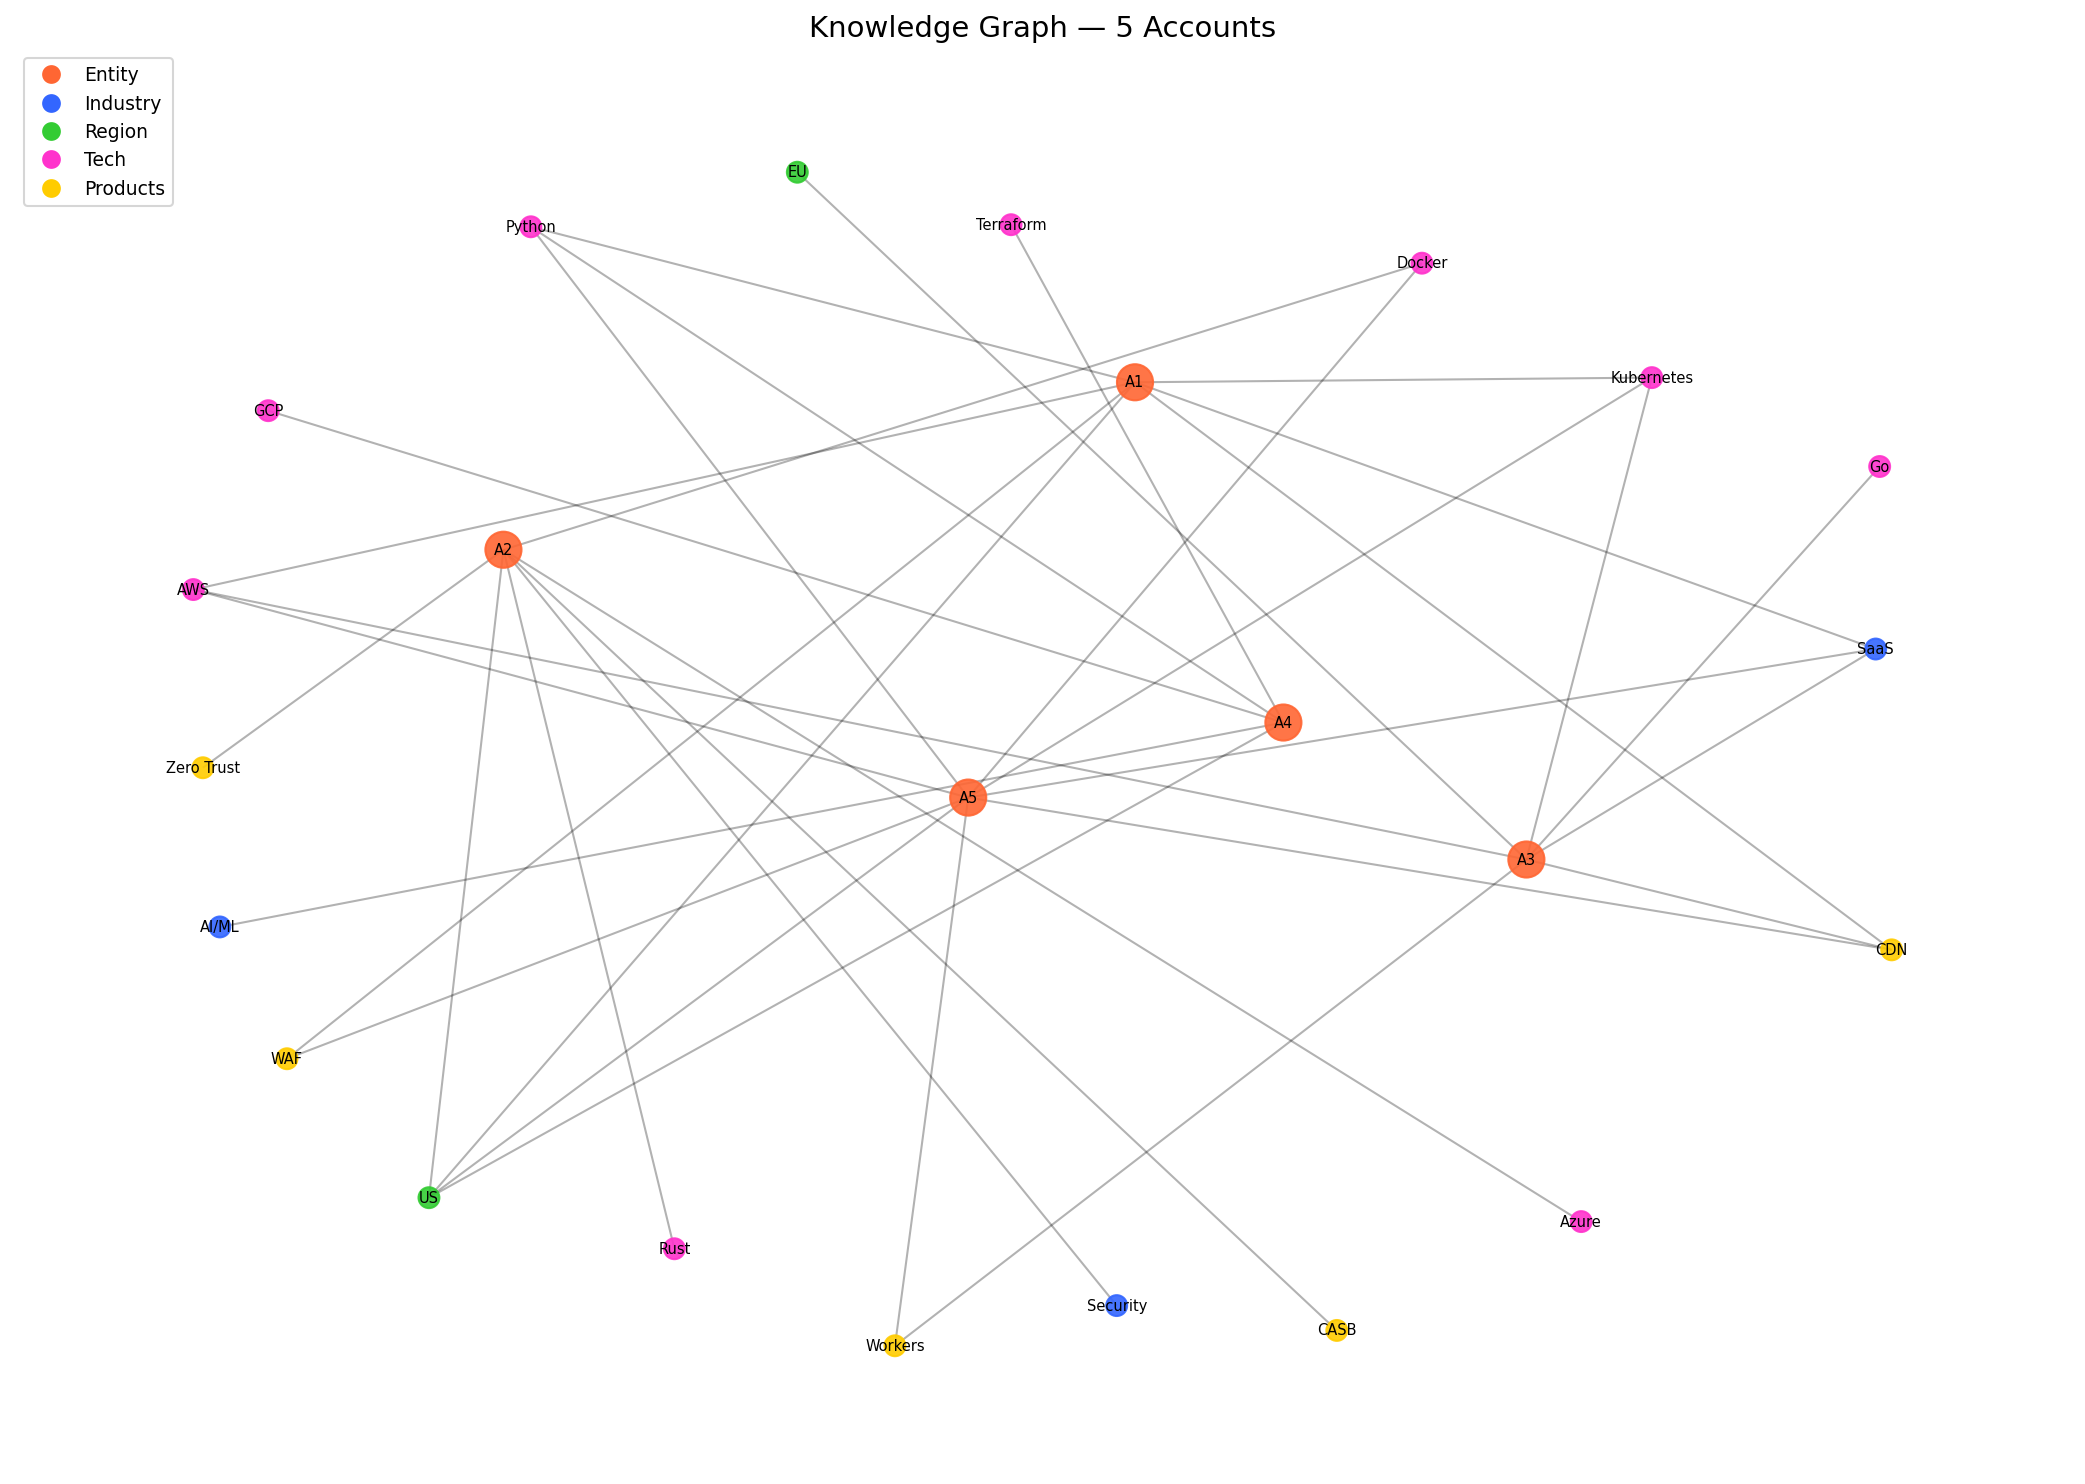

In [ ]:
import networkx as nx
import matplotlib.pyplot as plt

G = nx.Graph()
colors_map = {"entity": "#FF6633", "industry": "#3366FF", "region": "#33CC33",
              "tech": "#FF33CC", "products": "#FFCC00"}
node_colors, node_sizes, labels = [], [], {}

for nid in kg._entity_ids:
    G.add_node(nid); node_colors.append("#FF6633"); node_sizes.append(300)
    labels[nid] = kg._nodes[nid]["label"]
    for e in kg._typed_adj.get(nid, []):
        tgt = e["target"]; tn = kg._nodes.get(tgt, {})
        if tn.get("type") in ("company", "stage", "desc"): continue
        if tgt not in G:
            G.add_node(tgt)
            node_colors.append(colors_map.get(tn.get("type",""), "#CCC"))
            node_sizes.append(100); labels[tgt] = tn.get("label","")[:12]
        G.add_edge(nid, tgt)

pos = nx.spring_layout(G, seed=42, k=2)
plt.figure(figsize=(14, 10))
nx.draw_networkx_nodes(G, pos, node_color=node_colors, node_size=node_sizes, alpha=0.9)
nx.draw_networkx_edges(G, pos, alpha=0.3)
nx.draw_networkx_labels(G, pos, labels, font_size=7)
plt.title("Knowledge Graph"); plt.axis("off"); plt.tight_layout()
plt.show()


## 4. ML features (per entity → sklearn/XGBoost)

In [4]:
features = kg.to_feature_dicts()
print(f'{len(features)} entities × {len(next(iter(features.values())))} features')

entity, feats = list(features.items())[0]
print(f'\nSample ({entity}):')
for k, v in feats.items():
    if not k.startswith('HAS_COMPANY') and not k.startswith('HAS_DESC'):
        print(f'  {k}: {round(v, 4) if isinstance(v, float) else v}')

500 entities × 22 features

Sample (A0001):
  degree: 12
  clustering_coeff: 0.0
  community_id: 0
  community_size: 500
  pagerank: 0.0008
  HAS_INDUSTRY_degree: 1
  HAS_TECH_STACK_degree: 2
  HAS_PRODUCTS_INTERESTED_degree: 1
  IN_EMPLOYEES_RANGE_degree: 1


## 5. KNN distance features

In [5]:
knn = kg.knn_features(k=5, metric='graph')
for e in list(knn.keys())[:2]:
    d = knn[e]
    print(f'{e}:')
    print(f'  5-NN: {d["knn_entities"]}')
    print(f'  Avg distance: {d["knn_avg_distance"]}')
    if d['knn_min_distance']:
        print(f'  Min distance: {d["knn_min_distance"]}')

A0001:
  5-NN: ['A0218', 'A0235', 'A0078', 'A0100', 'A0134']
  Avg distance: 0.666
  Min distance: 0.6316

A0002:
  5-NN: ['A0015', 'A0081', 'A0414', 'A0108', 'A0365']
  Avg distance: 0.6906


## 6. Find similar accounts

In [6]:
target = records[0]['company']
similar = await kg.find_similar(target, top_k=3)
print(f"Similar to '{target}':")
for s in similar:
    print(f'  {s["entity"]}: score={s["score"]}, via={s["via"][:3]}')

Similar to 'Rodriguez Figueroa and Sanchez':
  A0004: score=0.5, via=['HAS_REGION:APAC']
  A0017: score=0.5, via=['HAS_REGION:APAC']
  A0019: score=0.5, via=['HAS_REGION:APAC']


## 7. Pairwise features (for link prediction / match scoring)

In [7]:
if similar:
    other = similar[0]['entity']
    pf = kg.pairwise_features(target, other)
    print(f'{target} ↔ {other}:')
    for k, v in pf.items():
        print(f'  {k}: {round(v, 3) if isinstance(v, float) else v}')

Rodriguez Figueroa and Sanchez ↔ A0004:
  shared_neighbors: 4
  jaccard: 0.143
  adamic_adar: 0.764
  cosine_similarity: 0.0
  same_community: 1.0


## 8. Neighborhood exploration

In [8]:
hood = kg.neighborhood(target, hops=1)
nt = {}
for n in hood['nodes']:
    nt[n['type']] = nt.get(n['type'], 0) + 1
print(f'1-hop neighborhood: {len(hood["nodes"])} nodes, {len(hood["edges"])} edges')
print(f'Node types: {', '.join(f'{k}={v}' for k, v in nt.items())}')

1-hop neighborhood: 13 nodes, 12 edges
Node types: entity=1, company=1, industry=1, region=1, segment=1, stage=1, description=1, tech_stack=2, products_interested=1, use_cases=1, employees_range=1, revenue_range=1


## 9. Match a new lead (partial attributes)

In [9]:
matches = await kg.match(industry='SaaS', region='US', top_k=3)
print(f'Match (SaaS + US):')
for m in matches:
    print(f'  {m["entity"]}: score={m["score"]}, matched={m["matched_on"]}')

Match (SaaS + US):
  A0363: score=2.0, matched=['industry=SaaS', 'region=US']
  A0168: score=2.0, matched=['industry=SaaS', 'region=US']
  A0080: score=2.0, matched=['industry=SaaS', 'region=US']


## 10. KNN rate features (peer adoption → propensity signals)

The key ML insight: if 80% of your graph peers own a product you don't, that's a strong propensity signal.

In [10]:
rates = kg.knn_rate_features(['products_owned', 'use_cases'], k=5)
entity = list(rates.keys())[0]
data = rates[entity]
high = {k: v for k, v in data.items() if k.startswith('knn_rate_') and isinstance(v, float) and v > 0.3}
print(f'{entity} peer adoption rates:')
for k, v in sorted(high.items(), key=lambda x: x[1], reverse=True)[:5]:
    print(f'  {k}: {v}')

A0001 peer adoption rates:
  knn_rate_cloud_security: 0.8
  knn_rate_edge_compute: 0.6
  knn_rate_data_protection: 0.4


## 11. Recommendations (what peers have that you don't)

In [11]:
cust = next(r for r in records if r['stage'] == 'Customer' and r['products_owned'])
print(f'{cust["account_id"]} owns: {cust["products_owned"]}')

recs = kg.recommend(cust['account_id'], ['products_owned'], k=5, min_rate=0.3)
print(f'\nRecommendations:')
for r in recs[:5]:
    n_peers = len(r['peer_votes'])
    n_have = sum(1 for c in r['peer_votes'] if c == '✓')
    print(f'  {r["value"]}: rate={r["rate"]:.2f} — {n_have}/{n_peers} structural peers have it')

A0002 owns: DDoS Protection

Recommendations:
  casb: rate=0.40 — 2/5 structural peers have it
  waf: rate=0.40 — 2/5 structural peers have it


## 12. Co-occurrence (which products are bought together)

In [12]:
co = kg.co_occurrence_features('products_owned')
for p in list(co.keys())[:2]:
    top = sorted(co[p].items(), key=lambda x: x[1], reverse=True)[:2]
    for other, rate in top:
        print(f'{p} + {other}: P={rate}')

ai gateway + r2: P=0.273
ai gateway + workers: P=0.273
casb + waf: P=0.407
casb + zero trust: P=0.370


## 13. Incremental updates (add new accounts)

In [13]:
before = len(kg._nodes)
await kg.add_records(
    [{'account_id': 'NEW1', 'company': 'NewCo', 'industry': 'SaaS', 'region': 'US',
      'segment': 'SMB', 'employees': 25, 'revenue': 1e6, 'stage': 'Prospect',
      'tech_stack': 'AWS, Kubernetes', 'products_owned': '', 'products_interested': 'Workers',
      'use_cases': 'edge_compute', 'description': 'New startup on CF.'}],
    data_dict=dd, extract_entities=False, compute_similarity=False,
)
print(f'Before: {before} nodes → After: {len(kg._nodes)} nodes')
new_sim = await kg.find_similar('NewCo', top_k=3)
print(f'NewCo similar to: {[s["entity"] for s in new_sim]}')

Before: 1553 nodes → After: 1556 nodes
NewCo similar to: ['A0001', 'A0002', 'A0003']


## 14. LLM Q&A over the graph (requires Workers AI)

Ask natural language questions grounded in graph data:

In [ ]:
# Requires CLOUDFLARE_ACCOUNT_ID and CLOUDFLARE_API_TOKEN
# answer = await kg.ask('Which industries have the most Enterprise accounts?')
# print(answer)

## 15. Feed into ML model

In [ ]:
# Combine all features into one dict per entity
all_features = {}
graph_feats = kg.to_feature_dicts()
knn_feats = kg.knn_features(k=5, metric='graph')
rate_feats = kg.knn_rate_features(['products_owned'], k=5)

for entity in graph_feats:
    all_features[entity] = {
        **graph_feats[entity],
        **{f'knn_{k}': v for k, v in knn_feats.get(entity, {}).items()
           if k in ('knn_avg_distance', 'knn_min_distance')},
        **{k: v for k, v in rate_feats.get(entity, {}).items()
           if k.startswith('knn_rate_')},
    }

# Ready for sklearn / XGBoost / LightGBM:
# import pandas as pd
# df = pd.DataFrame.from_dict(all_features, orient='index')
# X = df.drop(columns=['community_id'])  # features
# y = ...  # your target (churn, propensity, etc.)
# model = XGBClassifier().fit(X, y)

print(f'{len(all_features)} entities × {len(next(iter(all_features.values())))} total features')

## 16. Custom reference-group features (compute_feature)

Generate any feature relative to a reference group:

In [16]:
from pydantic_ai_cloudflare import compute_feature

f1 = compute_feature(kg, computation="shared_count",
    node_type="tech", reference_filter={"products": "zero trust"})
print("Shared tech with Zero Trust customers:")
for e, v in sorted(f1.items(), key=lambda x: x[1], reverse=True):
    print(f"  {e}: {int(v)}")

f2 = compute_feature(kg, computation="distance_to_nearest",
    reference_filter={"stage": "Customer", "industry": "SaaS"})
print("\nDistance to nearest SaaS customer:")
for e, v in sorted(f2.items(), key=lambda x: x[1]):
    print(f"  {e}: {int(v)} hops")

f3 = compute_feature(kg, computation="overlap_rate", node_type="tech",
    reference_filter={"stage": "Customer"})
print("\nTech overlap with all customers:")
for e, v in sorted(f3.items(), key=lambda x: x[1], reverse=True):
    print(f"  {e}: {v:.3f}")


Shared tech with Zero Trust customers:
  A5: 1
  A1: 0
  A2: 0
  A3: 0
  A4: 0

Distance to nearest SaaS customer:
  A1: 0 hops
  A3: 0 hops
  A5: 0 hops
  A2: 2 hops
  A4: 2 hops

Tech overlap with all customers:
  A5: 0.571
  A1: 0.429
  A3: 0.429
  A2: 0.429
  A4: 0.111


## 17. Temporal decay

Recent records have stronger edge weights. Old data fades:

In [17]:
for nid in kg._entity_ids:
    node = kg._nodes[nid]
    edges = kg._typed_adj.get(nid, [])
    avg_w = sum(e["weight"] for e in edges) / len(edges)
    data = node.get("data", {})
    print(f'{node["label"]:4s} ({data.get("company", ""):12s}) created={data.get("created", "?")}  weight={avg_w:.4f}')


A4 (DeltaAI)     created=2026-04-20  weight=0.9704
A1 (AlphaCloud)  created=2026-04-01  weight=0.8825
A3 (GammaData)   created=2026-03-20  weight=0.8311
A5 (EpsilonDev)  created=2026-01-10  weight=0.5886
A2 (BetaSecure)  created=2025-06-15  weight=0.2070


## Summary: What the graph gives you for ML

| Feature Type | Examples | ML Use Case |
|---|---|---|
| Structural | degree, clustering_coeff | Account complexity, engagement depth |
| Community | community_id, community_size | Market segmentation |
| Centrality | pagerank | Account importance / influence |
| KNN Distance | knn_avg_distance, knn_min_distance | Similarity to known accounts |
| KNN Rate | knn_rate_{product} | Propensity / upsell scoring |
| Co-occurrence | P(B\|A) | Cross-sell / bundle recommendations |
| Pairwise | jaccard, adamic_adar, shared_neighbors | Match scoring, deduplication |
| Per-edge-type | HAS_TECH_STACK_degree, HAS_INDUSTRY_degree | Feature specificity |

The graph finds signals a flat table cannot: structural peers, co-purchase patterns, community membership, and adoption rates among similar accounts.